In [1]:
!pip install opencv-python pixellib

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


고양이 이미지 크기: (255, 377, 3)
배경(사막) 이미지 크기: (254, 389, 3)
사람 이미지 크기: (567, 374, 3)


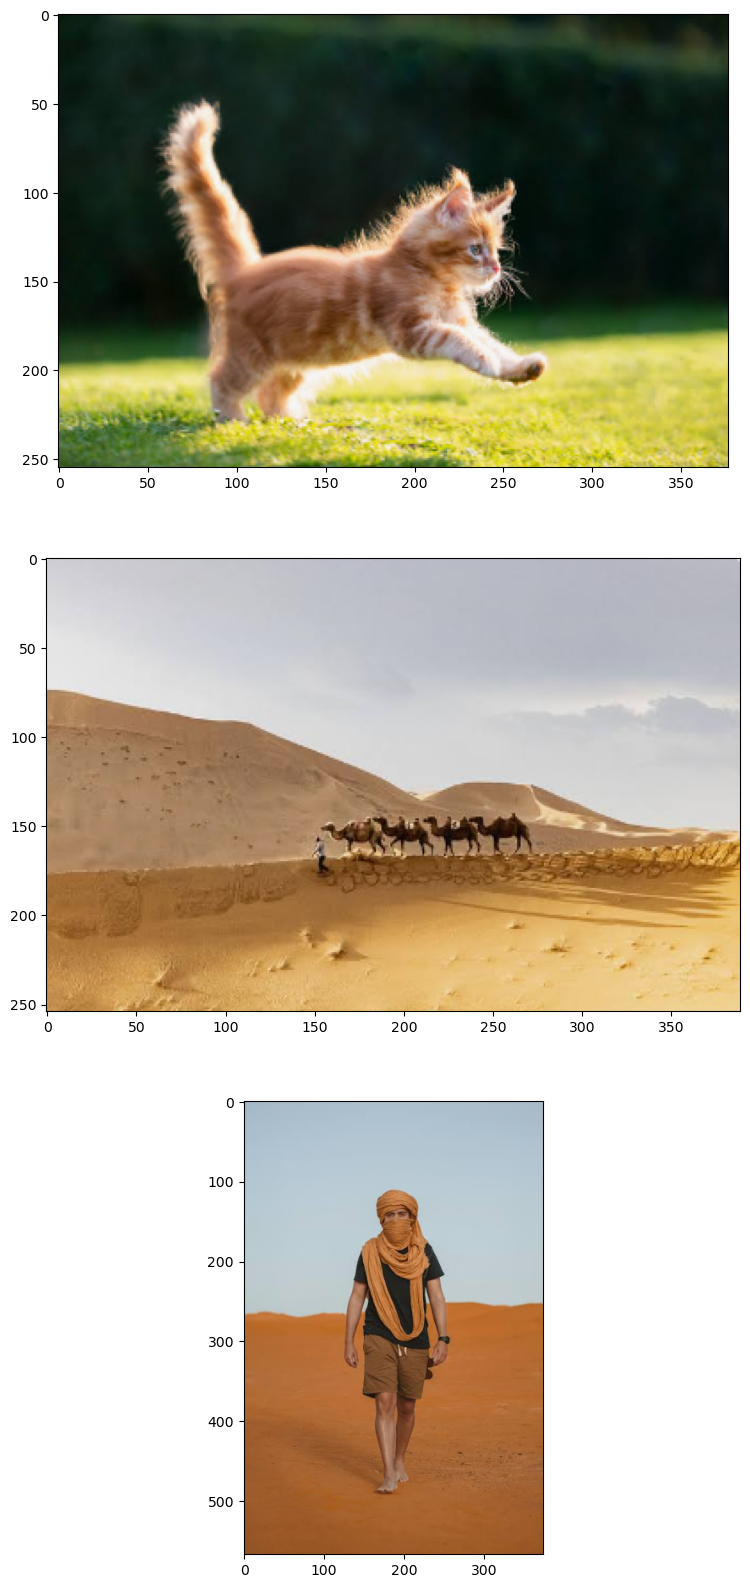

In [3]:
cat_img_path = "cat.png"  
sand_img_path = "sand.png"  
man_img_path = "man.png"

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)
man_img = cv2.imread(man_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)
man_img = cv2.cvtColor(man_img, cv2.COLOR_BGR2RGB)

print(f"고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")
print(f"사람 이미지 크기: {man_img.shape}")

plt.figure(figsize=(15, 20))
plt.subplot(3, 1, 1)
plt.imshow(cat_img)

plt.subplot(3, 1, 2)
plt.imshow(sand_img)

plt.subplot(3, 1, 3)
plt.imshow(man_img)

plt.show()

In [4]:
from torchvision.models.segmentation import DeepLabV3_ResNet101_Weights
# 이미 학습된 AI 모델 준비
model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).eval() # DeepLab은 “무엇인지”만 알지 “크기 조절”은 안 함  

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

# 모델은 학습할 수 있게 비슷한 크기로 맞춤
# .unsqueeze(0) : 텐서의 0번째 차원에 새로운 축을 추가하여 차원을 하나 늘려준다.
input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(output.shape)  # 0: 배경, 8: 고양이, 15: 사람 / (클래스수21, 높이520, 너비520)
print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

torch.Size([21, 520, 520])
추론 마스크 크기 (Before Resize): (520, 520)


현재 사용 중인 torchvision 버전이 업데이트되면서, 이전 방식인 pretrained=True 대신 새로운 권장 방식(weights)을 사용  
노드 코드: model = deeplabv3_resnet101(pretrained=True).eval() 에서 변경함.

In [5]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (255, 377)


In [6]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")
# 0 = background 8 = cat 검출

예측된 클래스 ID: [0 8]


58 274
51 229


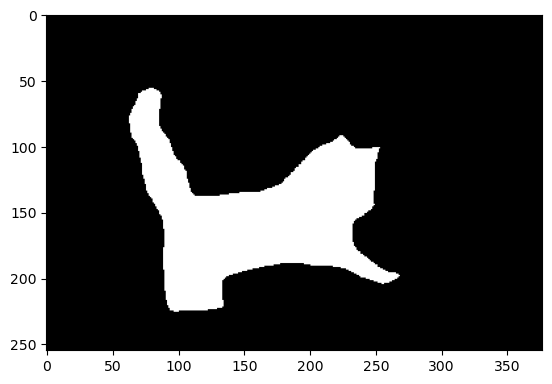

In [7]:
target_class_id = unique_classes[-1]
# unique_classes = [0 8] 이라면 unique_classes[-1]는 8. 즉 target_class_id = 8

seg_map = (output_predictions_resized == target_class_id)
# 0 == 8 → False , 8 == 8 → True . 최종적으로 배경 → False 고양이 → True


# 경계 자연스러워지게 코드 변경
mask = seg_map.astype(np.float32)
mask = cv2.GaussianBlur(mask, (51, 51), 0) # 경계 부드럽게 조절 - 너무 높이면 꼬리다리 얇아짐
mask = np.clip(mask, 0, 1)

img_mask = seg_map.astype(np.uint8) * 255

# 고양이 주변 깔끔하게 / 침식 + 블러 조합
kernel = np.ones((5,5), np.uint8)

img_mask = cv2.erode(img_mask, kernel, iterations=2)

ys, xs = np.where(seg_map)

print(xs.min(), xs.max())
print(ys.min(), ys.max())

y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

cat_crop = cat_img[y_min:y_max, x_min:x_max]

plt.imshow(img_mask, cmap='gray')
plt.show()

In [8]:
print(seg_map.shape)
print(seg_map.dtype)
print(np.sum(seg_map))

(255, 377)
bool
18502


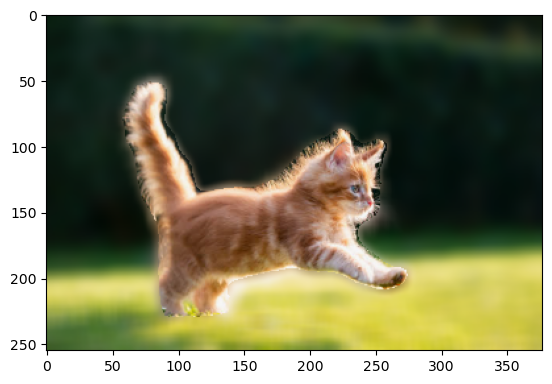

In [9]:
# cat 마스크 생성
seg_map = (output_predictions_resized == 8)  # 클래스 ID 15 (사람)
# 흑백 마스크 생성
cat_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
# 컬러 마스크 생성
color_mask = cv2.applyColorMap(cat_mask, cv2.COLORMAP_JET)

# 배경 흐리게 하기
cat_blur = cv2.blur(cat_img, (12, 12))

# 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출
cat_back = cv2.cvtColor(cat_mask, cv2.COLOR_GRAY2BGR)
cat_bg_mask = cv2.bitwise_not(cat_back)
cat_bg_blur = cv2.bitwise_and(cat_blur, cat_bg_mask)

# 흐린 배경과 원본 영상 합성
img_concat = np.where(cat_back==255, cat_img, cat_blur)

plt.imshow(img_concat)
plt.show()

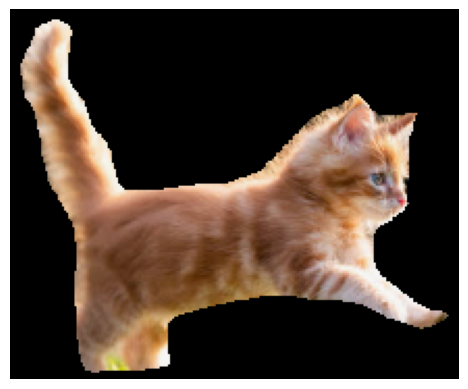

In [10]:
# 고양이 사진 잘라내기
mask_crop = img_mask[y_min:y_max, x_min:x_max] # 고양이 위치를 알려주는 지도
mask_crop_3ch = cv2.cvtColor(mask_crop, cv2.COLOR_GRAY2RGB)
cat_only = np.where(mask_crop_3ch == 255, cat_crop, 0)
plt.imshow(cat_only) # 고양이만 추출된 실제 이미지 _ 크기 줄이고 위치 이동에 사용
plt.axis("off")  # 축 정보 숨기기
plt.show()

In [11]:
# 고양이 사이즈 조절
scale = 0.4

cat_small = cv2.resize(cat_only, None, fx=scale, fy=scale)

mask_small = cv2.resize(mask_crop, None, fx=scale, fy=scale)

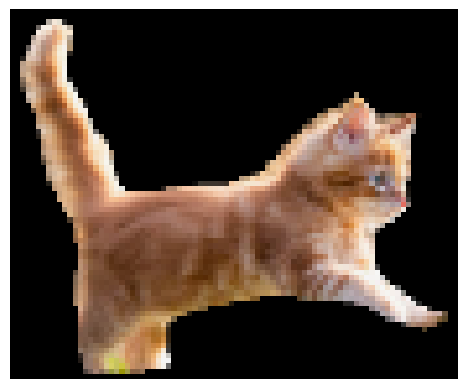

In [12]:
plt.imshow(cat_small)
plt.axis("off")
plt.show()

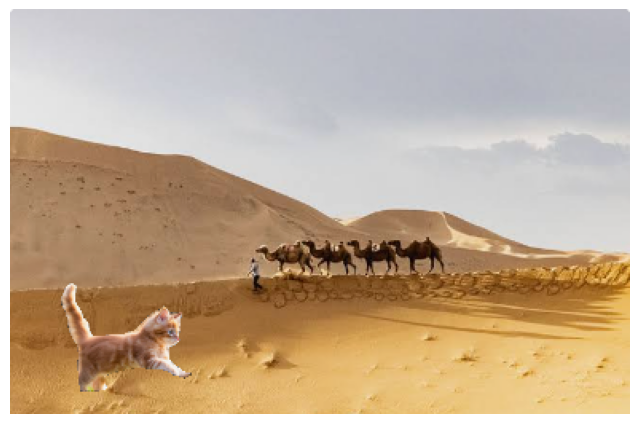

In [13]:
result_img = sand_img.copy()

x_offset = 30
y_offset = 170

h, w = cat_small.shape[:2]

roi = result_img[y_offset:y_offset+h, x_offset:x_offset+w]

mask_binary = mask_small > 128

roi[mask_binary] = cat_small[mask_binary]

plt.figure(figsize=(8,6))
plt.imshow(result_img)
plt.axis("off")
plt.show()

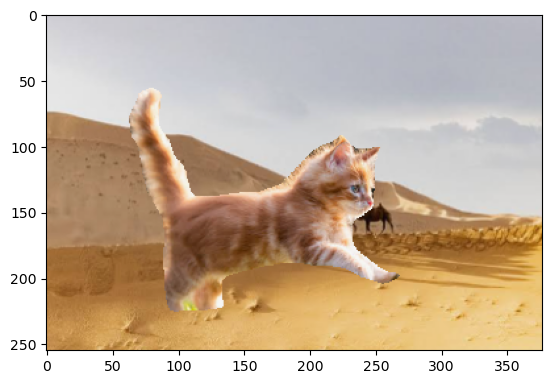

In [14]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성 , 고양이 크기 = 원본 cat_img 크기 사용

plt.imshow(result_img)
plt.show()

기존 코드로 진행하면 바로 위 이미지처럼 고양이가 사진 중앙에 위치  

-> 배경이미지에 어울리게 고양이 사이즈 조절.  
고양이 안티앨리어싱을 적절하게 조절하기 위해 코드를 추가하여 수정함.
고양이만 나오게 조절하고 싶었는데 털이랑 배경이랑 같이 어울러져있어 조절할수록 꼬리 다리가 얇아져서 지금 상태까지만 설정.

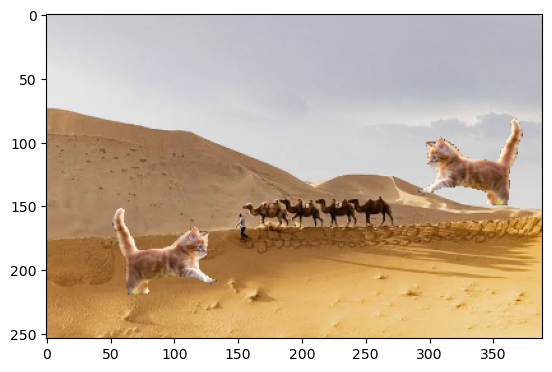

In [15]:
# 좌우반전 고양이 복사
cat_flip = cv2.flip(cat_small, 1)
mask_flip = cv2.flip(mask_small, 1)


def paste_object(background, obj, mask, x_offset, y_offset):
    
    h, w = obj.shape[:2]

    roi = background[y_offset:y_offset+h, x_offset:x_offset+w]

    mask_binary = mask > 128

    for c in range(3):
        roi[:, :, c] = np.where(mask_binary, obj[:, :, c], roi[:, :, c])

    return background

result_img = sand_img.copy()

result_img = paste_object(
    result_img,
    cat_small,
    mask_small,
    50,
    150
)

result_img = paste_object(
    result_img,
    cat_flip,
    mask_flip,
    290,
    80
)

plt.imshow(result_img)
plt.show()

In [16]:
# 사람이랑 사막
from torchvision.models.segmentation import DeepLabV3_ResNet101_Weights
model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  
    T.ToTensor(),
])


input_tensor = transform(man_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(output.shape) 
print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

output_predictions_resized = cv2.resize(output_predictions, (man_img.shape[1], man_img.shape[0]), interpolation=cv2.INTER_NEAREST)
print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

torch.Size([21, 520, 520])
추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (567, 374)
예측된 클래스 ID: [ 0 15]


15


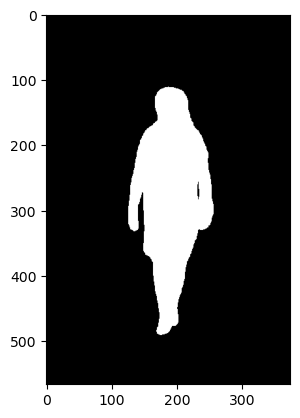

In [17]:
target_class_id = 15
print(target_class_id)

# AI 모델이 예측한 결과(마스크)에서 우리가 원하는 특정 대상의 위치만 골라내어, 눈으로 볼 수 있는 흑백 이미지 파일 형태(0과 255)로 변환하는 과정
# 우리가 찾고자 하는 대상(target_class_id)에 해당하는 픽셀만 True로, 나머지는 False로 분리
seg_map = (output_predictions_resized == target_class_id)
# 컴퓨터가 이미지로 출력할 수 있도록 0(검은색)과 255(흰색)의 디지털 숫자로 바꿈
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

126 256
111 491


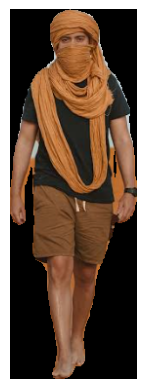

In [18]:
# 원하는 객체가 존재하는 픽셀의 위치(좌표)만 추출
ys, xs = np.where(seg_map)

print(xs.min(), xs.max())
print(ys.min(), ys.max())

y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

man_crop = man_img[y_min:y_max, x_min:x_max]

mask_crop = img_mask[y_min:y_max, x_min:x_max] 
mask_crop_3ch = cv2.cvtColor(mask_crop, cv2.COLOR_GRAY2RGB)
man_only = np.where(mask_crop_3ch == 255, man_crop, 0)
plt.imshow(man_only) 
plt.axis("off")
plt.show()

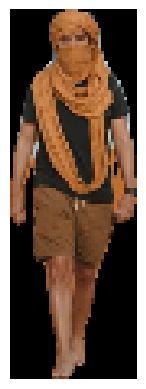

In [19]:
# 이미지 크기를 원본의 30% 수준으로 줄여서 합성
scale = 0.3

man_small = cv2.resize(man_only, None, fx=scale, fy=scale)

mask_small = cv2.resize(mask_crop, None, fx=scale, fy=scale)

plt.imshow(man_small)
plt.axis("off")
plt.show()

In [20]:
# 이미지 크기 확인
print("man_small:", man_small.shape)
print("mask_small:", mask_small.shape)
print("roi:", roi.shape)

print("sand:", sand_img.shape)
print("man_small:", man_small.shape)
print("x_offset:", x_offset)
print("y_offset:", y_offset)

print(y_offset + h)
print(x_offset + w)

man_small: (114, 39, 3)
mask_small: (114, 39)
roi: (71, 86, 3)
sand: (254, 389, 3)
man_small: (114, 39, 3)
x_offset: 30
y_offset: 170
241
116


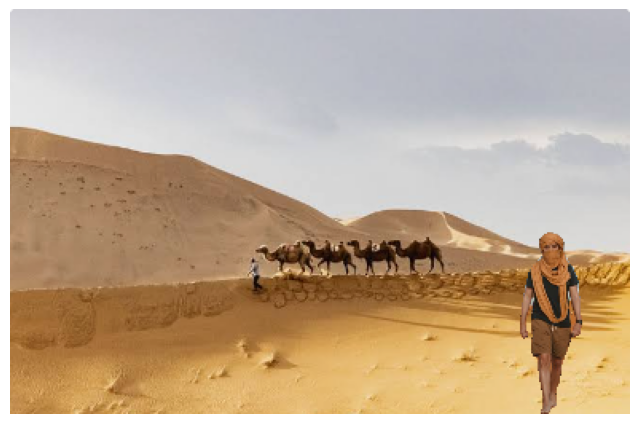

In [22]:
result_img = sand_img.copy()

x_offset = 320
y_offset = sand_img.shape[0] - h  # 254 -114 : 사람 발 바닥에 맞추기위해

h, w = man_small.shape[:2]

# 사막에 붙일 영역 선택 / (Region Of Interest 관심 영역)
roi = result_img[y_offset:y_offset+h, x_offset:x_offset+w]

# 마스크 만들기
mask_binary = mask_small > 128

# RGB 채널별 합성 (Red c=0, Green c=1, Blue c=2) / 스티커 붙이는 코드
for c in range(3): 
    roi[:, :, c] = np.where(mask_binary, man_small[:, :, c], roi[:, :, c])
    # 사람이면 → 사람 픽셀 사용 , 배경이면 → 원래 사막 픽셀 사용
    

plt.figure(figsize=(8,6))
plt.imshow(result_img)
plt.axis("off")
plt.show()

사람 이미지 크기: (567, 374, 3)


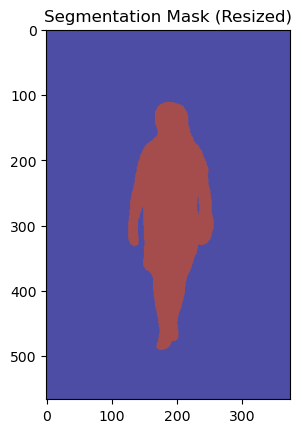

array([ 0, 15], dtype=uint8)

In [23]:
man_img_path = "man.png"
man_img = cv2.imread(man_img_path)
man_img = cv2.cvtColor(man_img, cv2.COLOR_BGR2RGB)
print(f"사람 이미지 크기: {man_img.shape}")
plt.show()

from torchvision.models.segmentation import DeepLabV3_ResNet101_Weights
model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).eval()

transform = T.Compose([T.ToPILImage(), T.Resize((520, 520)), T.ToTensor()])

input_tensor = transform(man_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

output_predictions_resized = cv2.resize(
    output_predictions,
    (man_img.shape[1], man_img.shape[0]),
    interpolation=cv2.INTER_NEAREST
)
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

# 클래스 확인
unique_classes = np.unique(output_predictions_resized)
unique_classes

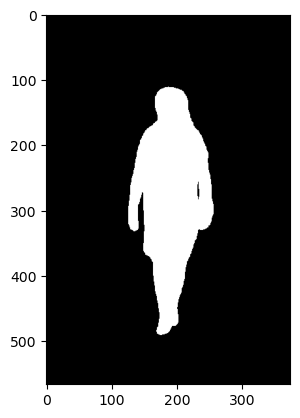

In [24]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
# **사람 마스크 생성**
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
# 흑백 마스크 생성
man_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
# 컬러 마스크 생성
color_mask = cv2.applyColorMap(man_mask, cv2.COLORMAP_JET)

plt.imshow(man_mask, cmap='gray')  # 흑백으로 표시
plt.show()

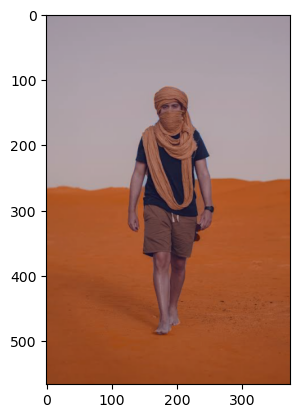

In [25]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다 (원본과 합성)

img_show = cv2.addWeighted(man_img, 0.8, color_mask, 0.2, 0.0)

# plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)) 위에서 설정해서 필요없다.
plt.imshow(img_show)
plt.show()

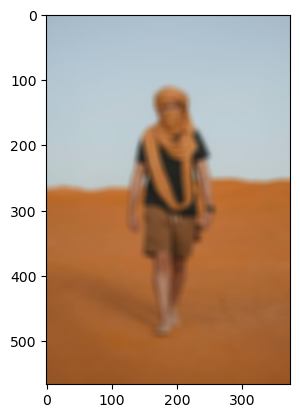

In [26]:
# (,)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
# 배경 흐리게 하기
man_img_blur = cv2.blur(man_img, (12, 12))

plt.imshow(man_img_blur)
plt.show()

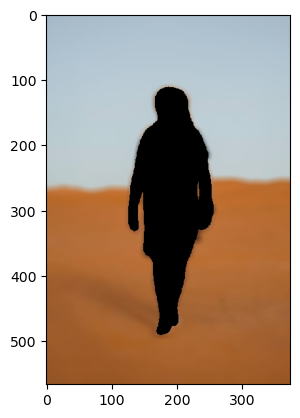

In [27]:
# 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
man_mask_color = cv2.cvtColor(man_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
man_bg_mask = cv2.bitwise_not(man_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
man_bg_blur = cv2.bitwise_and(man_img_blur, man_bg_mask)
plt.imshow(man_bg_blur)
plt.show()

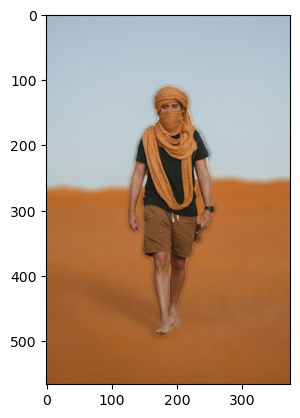

In [28]:
# 흐린 배경과 원본 영상 합성
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(man_mask_color==255, man_img, man_img_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(img_concat)
plt.show()

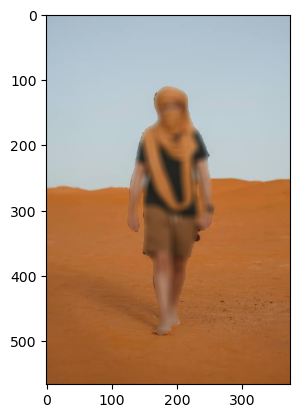

In [29]:
# 사람 부분을 블러로, 배경 부분을 원본으로 출력
img_concat = np.where(man_mask_color == 255, man_img_blur, man_img)
plt.imshow(img_concat)
plt.show()

이번 학습에선 사진에 사진을 잘라 붙이는데 지난시간에 이미지를 붙일때보다 코드가 많아지고 복잡해졌다.  
노드 학습에 제공된 코드는 np.where 방식으로 고양이 사진에서 배경만 교체해 고양이 사이즈는 그대로 유지 되었는데,  
코드를 수정해 ROI 합성 방식으로 합성할 사진의 사이즈 조절과 배경좌표 설정을 통해 위치 이동해 적절한 위치에 합성하였다.
사람 사진의 경우 사이즈가 커서 좌표확인하면서 수정을 거쳐야했다.